# Module 3 · Governed Indexing & Performance Optimization

**Story:** two related problems AMEX flagged — (1) an inefficient query
shape is eating cluster capacity, and (2) in-code index/schema creation
across app services causes drift and conflicts. This notebook addresses
both:

- **Part A** — detect a bad query shape, **block it live** cluster-wide with
  an Operation Rejection Filter (no app redeploy), fix it with an index,
  unblock it. This is the same signal Atlas **Performance Advisor** /
  **Query Insights** surface in the UI.
- **Part B** — retrofit **centralized schema validation** onto an existing
  collection, so the database itself rejects documents that don't match the
  agreed shape — instead of every app service enforcing (or not enforcing)
  its own rules at write time.

Requires **M10+ and MongoDB Server 8.0+** for Part A (Operation Rejection
Filters are an 8.0 feature and aren't available on Free/Flex clusters
regardless of version).


In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pymongo[encryption]", "certifi", "python-dotenv", "requests"],
        check=True,
    )
    from getpass import getpass
    ATLAS_URI = os.environ.get("ATLAS_URI") or getpass("Atlas connection string (ATLAS_URI): ")
else:
    from dotenv import load_dotenv
    load_dotenv()
    ATLAS_URI = os.environ["ATLAS_URI"]

DEMO_DB = os.environ.get("DEMO_DB", "amex_demo")
import certifi
CA_FILE = certifi.where()
print("Environment:", "Colab" if IN_COLAB else "local", "| DB:", DEMO_DB)

from pymongo import MongoClient

client = MongoClient(ATLAS_URI, tlsCAFile=CA_FILE)
db = client[DEMO_DB]
coll = db.transactions

print("Existing indexes on transactions:")
for idx in coll.list_indexes():
    print(" -", idx["name"], idx.get("key"))


Environment: local | DB: amex_demo
Existing indexes on transactions:


 - _id_ SON([('_id', 1)])


## Part A — Detect, block, fix, unblock

Pick a realistic support-desk query: "this customer's transactions at this
merchant." Neither field is indexed, so it's a full collection scan — and
because it's a two-field match, it's very selective (a handful of docs out
of 50,000), which is exactly the shape that's expensive to scan for and
cheap to fetch once found.


In [2]:
import time

sample = coll.find_one({})
target_customer_id = sample["customer_id"]
target_merchant = sample["merchant"]
target_filter = {"customer_id": target_customer_id, "merchant": target_merchant}

match_count = coll.count_documents(target_filter)
print(f"Target query: customer_id={target_customer_id!r}, merchant={target_merchant!r}")
print(f"Matches {match_count} of 50,000 documents.")

latencies_before = []
for _ in range(30):
    start = time.perf_counter()
    list(coll.find(target_filter))
    latencies_before.append((time.perf_counter() - start) * 1000)

print(f"Ran 30x. Avg latency: {sum(latencies_before)/len(latencies_before):.1f} ms")


Target query: customer_id='CUST001309', merchant='Delta Air Lines'
Matches 4 of 50,000 documents.


Ran 30x. Avg latency: 156.9 ms


In [3]:
plan = coll.find(target_filter).explain()
stats = plan["executionStats"]
print("planSummary:", plan["queryPlanner"]["winningPlan"].get("stage"))
print("docsExamined:", stats["totalDocsExamined"])
print("nReturned:", stats["nReturned"])
print("scanned:returned ratio:",
      round(stats["totalDocsExamined"] / max(stats["nReturned"], 1), 1), ": 1")


planSummary: COLLSCAN
docsExamined: 50000
nReturned: 4
scanned:returned ratio: 12500.0 : 1


That ratio is exactly what triggers an Atlas **Query Targeting** alert
(default threshold 1000:1) and what Performance Advisor uses to recommend an
index. In the Atlas UI this same query shows up under **Query Insights →
Query Shape Insights**.

Now use an **Operation Rejection Filter** (`setQuerySettings` with `reject:
true`) to stop this exact query shape from running cluster-wide — right now,
without touching the application.


In [4]:
# setQuerySettings is an admin command (mongosh: db.adminCommand) — run it via
# the admin database, not the demo database. Requires MongoDB 8.0+.
client.admin.command({
    "setQuerySettings": {
        "find": "transactions",
        "filter": {"customer_id": {"$eq": "?"}, "merchant": {"$eq": "?"}},
        "$db": DEMO_DB,
    },
    "settings": {
        "reject": True,
        "comment": "AMEX demo: blocked unindexed customer+merchant lookup",
    },
})
print("Query shape blocked.")


Query shape blocked.


In [5]:
# Confirm it: the next attempt to run this query shape should fail immediately.
try:
    list(coll.find(target_filter))
    print("Query ran — unexpected, check that the filter shape matches exactly.")
except Exception as e:
    print("Rejected as expected:")
    print(" ", e)


Rejected as expected:
  Query rejected by admin query settings, full error: {'ok': 0.0, 'errmsg': 'Query rejected by admin query settings', 'code': 411, 'codeName': 'QueryRejectedBySettings', '$clusterTime': {'clusterTime': Timestamp(1787183887, 1), 'signature': {'hash': b'\xfdxK\xed\xab\xb6xQ\xf9Y\xe5X\xc1\x11\xc0\n\xe8\xc3[\x83', 'keyId': 7642949489266786305}}, 'operationTime': Timestamp(1787183887, 1)}


In [6]:
coll.create_index([("customer_id", 1), ("merchant", 1)])

plan_after = coll.find(target_filter).explain()
stats_after = plan_after["executionStats"]
print("planSummary:", plan_after["queryPlanner"]["winningPlan"].get("stage"))
print("docsExamined:", stats_after["totalDocsExamined"])
print("nReturned:", stats_after["nReturned"])


planSummary: FETCH
docsExamined: 4
nReturned: 4


In [7]:
# Now that it's indexed, remove the rejection filter. removeQuerySettings
# takes the queryShapeHash — fetch it via $querySettings first (this is also
# how you'd audit what's currently blocked cluster-wide).
current_settings = list(db.aggregate([{"$querySettings": {}}]))
for s in current_settings:
    print(s["queryShapeHash"], "->", s.get("representativeQuery"), "reject=", s["settings"].get("reject"))

target_hash = next(
    s["queryShapeHash"] for s in current_settings
    if "customer_id" in str(s.get("representativeQuery", {}))
)
client.admin.command({"removeQuerySettings": target_hash})
print("Unblocked.")


C79A81FD99FB989EC8D12838452EEE9E1EEC9559205611B6DA189FCEDC3C34E7 -> {'find': 'transactions', 'filter': {'customer_id': {'$eq': '?'}, 'merchant': {'$eq': '?'}}, '$db': 'amex_demo'} reject= True


Unblocked.


In [8]:
latencies_after = []
for _ in range(30):
    start = time.perf_counter()
    list(coll.find(target_filter))
    latencies_after.append((time.perf_counter() - start) * 1000)

print(f"Before index: {sum(latencies_before)/len(latencies_before):.1f} ms avg")
print(f"After index:  {sum(latencies_after)/len(latencies_after):.1f} ms avg")


Before index: 156.9 ms avg
After index:  87.7 ms avg


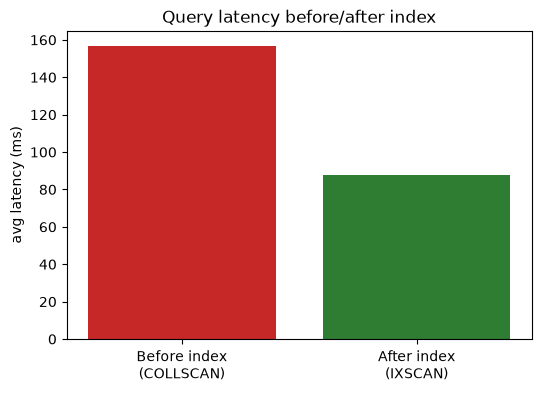

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Before index\n(COLLSCAN)", "After index\n(IXSCAN)"],
       [sum(latencies_before)/len(latencies_before), sum(latencies_after)/len(latencies_after)],
       color=["#c62828", "#2e7d32"])
ax.set_ylabel("avg latency (ms)")
ax.set_title("Query latency before/after index")
plt.show()


## Part B — Centralized schema validation

The other half of the "index drift and code conflicts" pain point: rather
than every app service enforcing its own idea of what a `transactions`
document looks like, retrofit a `$jsonSchema` validator directly onto the
collection. This is a **moderate** validation level — it applies to new
inserts and to updates of already-valid documents, without breaking
whatever's already there.


In [10]:
validator = {
    "$jsonSchema": {
        "bsonType": "object",
        "title": "transactions — centrally governed schema",
        "required": ["transaction_id", "customer_id", "amount", "status"],
        "properties": {
            "transaction_id": {"bsonType": "string"},
            "customer_id": {"bsonType": "string"},
            "amount": {"bsonType": ["double", "int"], "minimum": 0},
            "status": {"enum": ["approved", "declined", "pending"]},
        },
    }
}

db.command({
    "collMod": "transactions",
    "validator": validator,
    "validationLevel": "moderate",
    "validationAction": "error",
})
print("Schema validation applied to transactions.")


Schema validation applied to transactions.


In [11]:
# An app service tries to write a document that doesn't match the agreed schema.
try:
    coll.insert_one({
        "transaction_id": "BAD0001",
        "customer_id": "CUST999999",
        "amount": -50,               # violates minimum: 0
        "status": "not_a_real_status",  # violates enum
    })
    print("Insert succeeded — unexpected.")
except Exception as e:
    print("Rejected by schema validation, as expected:")
    print(" ", e)


Rejected by schema validation, as expected:
  Document failed validation, full error: {'index': 0, 'code': 121, 'errmsg': 'Document failed validation', 'errInfo': {'failingDocumentId': ObjectId('6a86431393bbc42afc04eec0'), 'details': {'operatorName': '$jsonSchema', 'title': 'transactions — centrally governed schema', 'schemaRulesNotSatisfied': [{'operatorName': 'properties', 'propertiesNotSatisfied': [{'propertyName': 'amount', 'details': [{'operatorName': 'minimum', 'specifiedAs': {'minimum': 0}, 'reason': 'comparison failed', 'consideredValue': -50}]}, {'propertyName': 'status', 'details': [{'operatorName': 'enum', 'specifiedAs': {'enum': ['approved', 'declined', 'pending']}, 'reason': 'value was not found in enum', 'consideredValue': 'not_a_real_status'}]}]}]}}}


In [12]:
# A compliant document still writes normally.
coll.insert_one({
    "transaction_id": "GOOD0001",
    "customer_id": "CUST000000",
    "account_id": "DEMO-ACCT",
    "amount": 42.50,
    "merchant": "Demo Merchant",
    "status": "approved",
    "timestamp": __import__("datetime").datetime.now(__import__("datetime").timezone.utc),
})
print("Compliant document inserted.")


Compliant document inserted.


In [13]:
# Clean up: remove the validator and the two demo documents, so this
# notebook is safe to re-run and doesn't affect other notebooks.
db.command({"collMod": "transactions", "validator": {}, "validationLevel": "off"})
coll.delete_many({"transaction_id": {"$in": ["BAD0001", "GOOD0001"]}})
print("Validator removed, demo documents cleaned up.")


Validator removed, demo documents cleaned up.


### Presenter talking points

- Operation Rejection Filters give ops a **circuit breaker** for a bad query
  shape — protect the cluster in seconds, without an app deploy or an
  incident bridge. Percona/MySQL has no real equivalent without an external
  proxy layer (ProxySQL rules, etc.).
- Schema validation moves the "what does a valid document look like"
  decision out of each app service's code and into the database itself —
  directly addresses index/schema drift from in-code collection creation.
- Recommended operational pattern: keep both the indexes and the validator
  definition in version control, applied via CI/CD migrations — not created
  ad hoc at runtime by application code.
